## conditional Diffusion Training

## Plan 

1. Understand the intuition behind diffusion-based generation.  
2. Implement a small **Conditional Denoising Diffusion Probabilistic Model (DDPM)** in PyTorch.  
3. Train it on the MNIST dataset and visualise results.  
4. Compare it briefly to a pre-built model from Hugging Face Diffusers.

## Recap - Diffusion Models

Unlike GANs, which learn via competition, diffusion models learn by **gradually denoising data**.

1. **Forward Process:** Adds noise step-by-step to an image until it becomes pure noise.  
2. **Reverse Process:** Learns to remove noise — reconstructing clean samples.

If the model can learn to reverse this noise for each timestep, it can start from random noise and “paint” an image.

In our case, we’ll condition the denoiser on digit labels (0–9) to control which digit is drawn.

In [1]:
# Import core libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
import warnings
import os
import sys

from model.diffusion import ConditionalUNet
from training.train_diffusion import train_diffusion, sample_images
from data_utils.dataloader import get_mnist_loaders
from utils.visualize import show_batch
from utils.checkpoint import load_checkpoint

warnings.filterwarnings("ignore")

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Using device: {device}")

Using device: cuda


###  Let’s configure a small diffusion system suitable for MNIST (28×28 grayscale).



In [2]:
# Hyperparameters
img_shape = (1, 28, 28)
num_classes = 10
timesteps = 200   # number of diffusion steps
batch_size = 128
epochs = 40
lr = 1e-4



In [3]:
# Extract the data
# Load MNIST train and test dataloaders using the helper function

train_loader, test_loader = get_mnist_loaders(batch_size=batch_size)

# Inspect one batch
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Min pixel value:", images.min().item())
print("Max pixel value:", images.max().item())
print("Sample labels:", labels[:10])

Images shape: torch.Size([128, 1, 28, 28])
Labels shape: torch.Size([128])
Min pixel value: -1.0
Max pixel value: 1.0
Sample labels: tensor([7, 0, 5, 1, 9, 0, 4, 4, 1, 1])


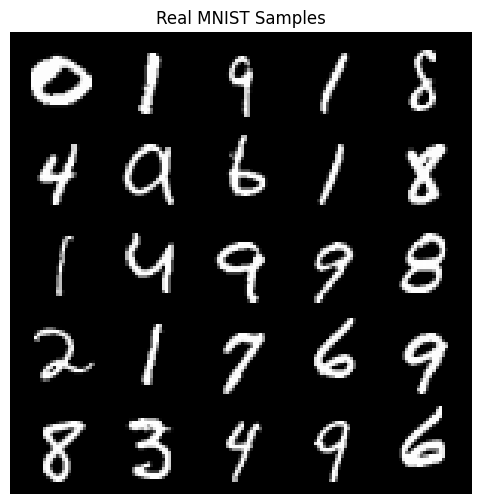

Labels: [0, 1, 9, 1, 8, 4, 9, 6, 1, 8, 1, 4, 9, 9, 8, 2, 1, 7, 6, 9, 8, 3, 4, 9, 6]


In [4]:
# Visualize real MNIST images

real_images, real_labels = next(iter(train_loader))

grid = make_grid(real_images[:25], nrow=5, normalize=True)

plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title("Real MNIST Samples")
plt.axis("off")
plt.show()

print("Labels:", real_labels[:25].tolist())

## Diffusion Model Architecture 

Our diffusion model will use a **U-Net** as the denoiser — a convolutional architecture that captures both local and global context.  
We’ll add:
- **Timestep embeddings** so the model knows “how noisy” the input is.
- **Label embeddings** for conditional generation.


### Training Loop

Our training objective is to predict the noise that was added at each timestep.  
We’ll use **Mean Squared Error (MSE)** between the predicted and actual noise.

In [5]:
# Initialize Conditional U-Net model

diffusion_model = ConditionalUNet(
    num_classes=num_classes,
    img_channels=img_shape[0],
    base_channels=64,
    time_dim=128
).to(device)

print(diffusion_model)

ConditionalUNet(
  (time_mlp): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (down1): ResidualBlock(
    (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
    (time_emb): Linear(in_features=128, out_features=64, bias=True)
    (label_emb): Embedding(10, 64)
    (shortcut): Conv2d(1, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (down2): ResidualBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 128, eps=1e-05, affine=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 128, eps=1e-05, affine=True)
    (time_emb): Linear(in_features=128, out_features=

In [6]:
# Quick forward-pass test before training

diffusion_model.eval()

with torch.no_grad():
    test_imgs = torch.randn(8, *img_shape, device=device)
    test_timesteps = torch.randint(0, timesteps, (8,), device=device)
    test_labels = torch.randint(0, num_classes, (8,), device=device)

    predicted_noise = diffusion_model(test_imgs, test_timesteps, test_labels)

print("Input shape:", test_imgs.shape)
print("Predicted noise shape:", predicted_noise.shape)

diffusion_model.train()

Input shape: torch.Size([8, 1, 28, 28])
Predicted noise shape: torch.Size([8, 1, 28, 28])


ConditionalUNet(
  (time_mlp): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (down1): ResidualBlock(
    (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
    (time_emb): Linear(in_features=128, out_features=64, bias=True)
    (label_emb): Embedding(10, 64)
    (shortcut): Conv2d(1, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (down2): ResidualBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm1): GroupNorm(8, 128, eps=1e-05, affine=True)
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (norm2): GroupNorm(8, 128, eps=1e-05, affine=True)
    (time_emb): Linear(in_features=128, out_features=

In [7]:
# Train Conditional Diffusion Model

diffusion_losses = train_diffusion(
    model=diffusion_model,
    dataloader=train_loader,
    device=device,
    num_classes=num_classes,
    timesteps=timesteps,
    epochs=epochs,
    lr=lr,
    checkpoint_dir="checkpoints",
    save_every=5
)

Epoch 1/40: 100%|██████████| 469/469 [00:59<00:00,  7.83it/s, loss=0.0896]


Epoch 1/40 completed. Average Loss: 0.1510


Epoch 2/40: 100%|██████████| 469/469 [00:58<00:00,  7.98it/s, loss=0.0538]


Epoch 2/40 completed. Average Loss: 0.0698


Epoch 3/40: 100%|██████████| 469/469 [00:58<00:00,  8.00it/s, loss=0.0555]


...

Epoch 38/40 completed. Average Loss: 0.0438


Epoch 39/40: 100%|██████████| 469/469 [00:58<00:00,  8.06it/s, loss=0.0477]


Epoch 39/40 completed. Average Loss: 0.0439


Epoch 40/40: 100%|██████████| 469/469 [00:58<00:00,  8.06it/s, loss=0.043] 


Epoch 40/40 completed. Average Loss: 0.0437
Saved diffusion checkpoint: checkpoints/diffusion_unet_epoch_40.pt
Final diffusion model saved at: checkpoints/diffusion_unet_final.pt


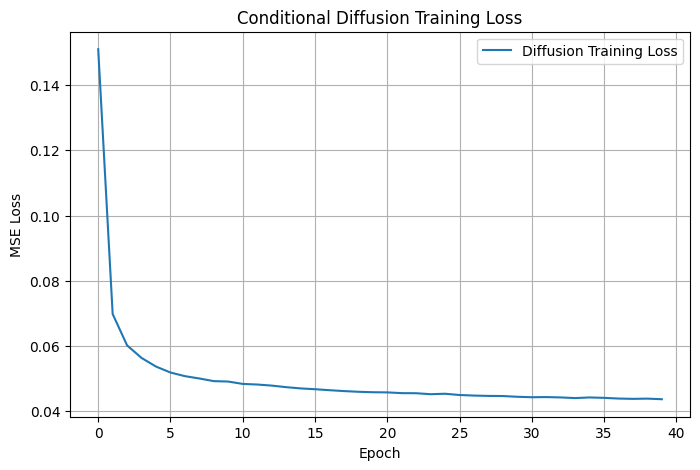

In [8]:
# Plot diffusion training loss

plt.figure(figsize=(8, 5))
plt.plot(diffusion_losses, label="Diffusion Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Conditional Diffusion Training Loss")
plt.legend()
plt.grid(True)
plt.show()

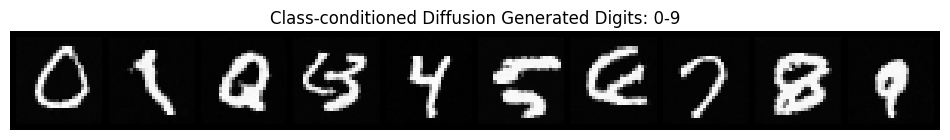

Generated labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [9]:
# Generate one synthetic digit for each class 0-9 using reverse diffusion

diffusion_model.eval()

class_labels = torch.arange(0, num_classes, device=device)

generated_images, generated_labels = sample_images(
    model=diffusion_model,
    device=device,
    num_samples=num_classes,
    num_classes=num_classes,
    img_size=img_shape,
    timesteps=timesteps,
    class_labels=class_labels
)

grid = make_grid(generated_images, nrow=10, normalize=True)

plt.figure(figsize=(12, 2))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title("Class-conditioned Diffusion Generated Digits: 0-9")
plt.axis("off")
plt.show()

print("Generated labels:", generated_labels.cpu().tolist())

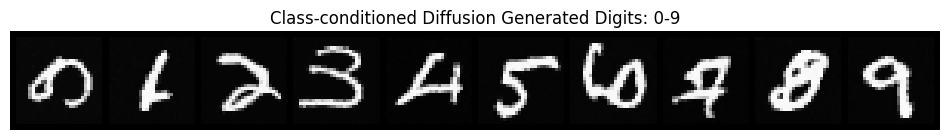

Generated labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [10]:
# Generate one synthetic digit for each class 0-9 using reverse diffusion

diffusion_model.eval()

class_labels = torch.arange(0, num_classes, device=device)

generated_images, generated_labels = sample_images(
    model=diffusion_model,
    device=device,
    num_samples=num_classes,
    num_classes=num_classes,
    img_size=img_shape,
    timesteps=timesteps,
    class_labels=class_labels
)

grid = make_grid(generated_images, nrow=10, normalize=True)

plt.figure(figsize=(12, 2))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title("Class-conditioned Diffusion Generated Digits: 0-9")
plt.axis("off")
plt.show()

print("Generated labels:", generated_labels.cpu().tolist())

In [11]:
# Save final Conditional Diffusion model

os.makedirs("checkpoints", exist_ok=True)

torch.save(
    {
        "model_state_dict": diffusion_model.state_dict(),
        "losses": diffusion_losses,
        "timesteps": timesteps,
        "num_classes": num_classes,
        "img_shape": img_shape,
    },
    "checkpoints/diffusion_unet_final_notebook.pt"
)

print("Final diffusion model saved at: checkpoints/diffusion_unet_final_notebook.pt")

Final diffusion model saved at: checkpoints/diffusion_unet_final_notebook.pt


### Training Behavior

We can observe that the diffusion model loss decreases gradually during training. Unlike GANs, diffusion models usually train in a more stable way because the objective is based on direct noise prediction using MSE loss, rather than an adversarial minimax game.

However, diffusion models are typically slower to converge because they learn to denoise images across many different timesteps. As training progresses, the model becomes better at predicting the noise added during the forward diffusion process, which improves the quality of generated samples during reverse denoising.

In [16]:

# Load final trained diffusion model weights

import os
import glob
import torch

num_classes = 10

model = ConditionalUNet(
    num_classes=num_classes,
    img_channels=img_shape[0],
    base_channels=64,
    time_dim=128
).to(device)

# Look for available diffusion checkpoints
checkpoint_candidates = [
    "checkpoints/diffusion_unet_final.pt",
    "checkpoints/diffusion_unet_final_notebook.pt",
]

# Also include any epoch checkpoint if final checkpoint is not found
checkpoint_candidates.extend(
    sorted(glob.glob("checkpoints/diffusion_unet_epoch_*.pt"))
)

existing_checkpoints = [path for path in checkpoint_candidates if os.path.exists(path)]

print("Available checkpoints:")
for path in existing_checkpoints:
    print("-", path)

if len(existing_checkpoints) == 0:
    raise FileNotFoundError(
        "No diffusion checkpoint found. Please run the diffusion training cell first."
    )

# Prefer final checkpoint if available; otherwise use the latest epoch checkpoint
if os.path.exists("checkpoints/diffusion_unet_final.pt"):
    checkpoint_path = "checkpoints/diffusion_unet_final.pt"
elif os.path.exists("checkpoints/diffusion_unet_final_notebook.pt"):
    checkpoint_path = "checkpoints/diffusion_unet_final_notebook.pt"
else:
    checkpoint_path = existing_checkpoints[-1]

print("Loading checkpoint:", checkpoint_path)

checkpoint = torch.load(checkpoint_path, map_location=device)

# Support both possible checkpoint formats
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
elif isinstance(checkpoint, dict) and "model_state" in checkpoint:
    model.load_state_dict(checkpoint["model_state"])
else:
    model.load_state_dict(checkpoint)

model.eval()

print("Diffusion model loaded successfully.")

Available checkpoints:
- checkpoints/diffusion_unet_final.pt
- checkpoints/diffusion_unet_final_notebook.pt
- checkpoints/diffusion_unet_epoch_10.pt
- checkpoints/diffusion_unet_epoch_15.pt
- checkpoints/diffusion_unet_epoch_20.pt
- checkpoints/diffusion_unet_epoch_25.pt
- checkpoints/diffusion_unet_epoch_30.pt
- checkpoints/diffusion_unet_epoch_35.pt
- checkpoints/diffusion_unet_epoch_40.pt
- checkpoints/diffusion_unet_epoch_5.pt
Loading checkpoint: checkpoints/diffusion_unet_final.pt
Diffusion model loaded successfully.


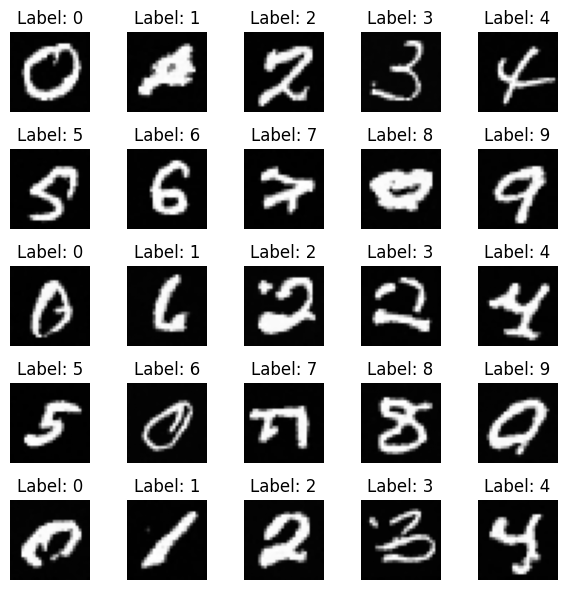

In [17]:
# sample images 

gen_imgs, labels = sample_images(model, device, num_samples=25, num_classes=num_classes)
show_batch(gen_imgs.to(device), labels.to(device), n=25)

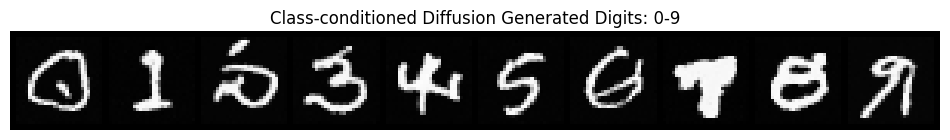

Generated labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [18]:
# Generate class-conditioned samples from the trained diffusion model

diffusion_model.eval()

class_labels = torch.arange(0, num_classes, device=device)

generated_images, generated_labels = sample_images(
    model=diffusion_model,
    device=device,
    num_samples=num_classes,
    num_classes=num_classes,
    img_size=img_shape,
    timesteps=timesteps,
    class_labels=class_labels
)

grid = make_grid(generated_images, nrow=10, normalize=True)

plt.figure(figsize=(12, 2))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title("Class-conditioned Diffusion Generated Digits: 0-9")
plt.axis("off")
plt.show()

print("Generated labels:", generated_labels.cpu().tolist())

In [19]:
# Save generated diffusion samples for later evaluation

os.makedirs("outputs", exist_ok=True)

torch.save(
    {
        "images": generated_images.cpu(),
        "labels": generated_labels.cpu(),
    },
    "outputs/diffusion_generated_samples.pt"
)

print("Generated diffusion samples saved at: outputs/diffusion_generated_samples.pt")

Generated diffusion samples saved at: outputs/diffusion_generated_samples.pt


In [20]:
# Save final Conditional Diffusion model explicitly

os.makedirs("checkpoints", exist_ok=True)

torch.save(
    {
        "model_state_dict": diffusion_model.state_dict(),
        "losses": diffusion_losses,
        "timesteps": timesteps,
        "num_classes": num_classes,
        "img_shape": img_shape,
    },
    "checkpoints/diffusion_unet_final_notebook.pt"
)

print("Final diffusion model saved at: checkpoints/diffusion_unet_final_notebook.pt")

Final diffusion model saved at: checkpoints/diffusion_unet_final_notebook.pt


### Diffusion Sampling Results

The Conditional Diffusion Model generates digit samples by starting from random Gaussian noise and progressively denoising the image through the reverse diffusion process. Each generated image is conditioned on a target class label from 0 to 9.

Compared with GAN training, diffusion training is generally more stable because the model directly learns to predict the noise added at each timestep using an MSE objective. However, the sampling process is slower because it requires multiple denoising steps to generate each image.

These generated samples will be used later in the evaluation notebook to compare visual quality, diversity, FID score, and downstream classifier utility against the cGAN-generated samples.